# Prediction Market Market Calculations— Jupyter Notebook
## Benjamin Scheinberg

The notebook is the supplemental calculations for the **Prediction Market Funds** product report.   

In [5]:
## double stacked chart of non-sports to sports prediction market volume
## in dune!

In [3]:
## comps between derivatives and reinsurance markets


## ASSUMPTION:
THERE ARE NO SERIOUS HEDGERS USING PREDICTION MARKETS YET

In [ ]:
## sankey profitability

# 1 volume of nonsports prediction markets
# ratio of ETFs to regular stocks (30%)
# fee extraction from etfs
# fees from using aggregation
# listing fees


In [4]:
## profitabilty sensitivity

# fee table by volume traded
# fee table by funds launched

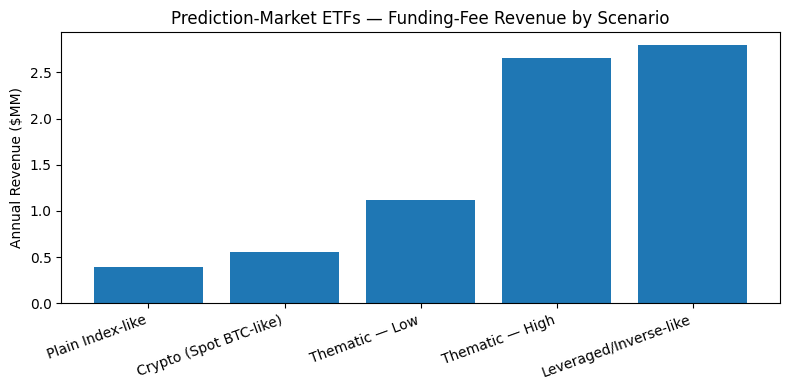

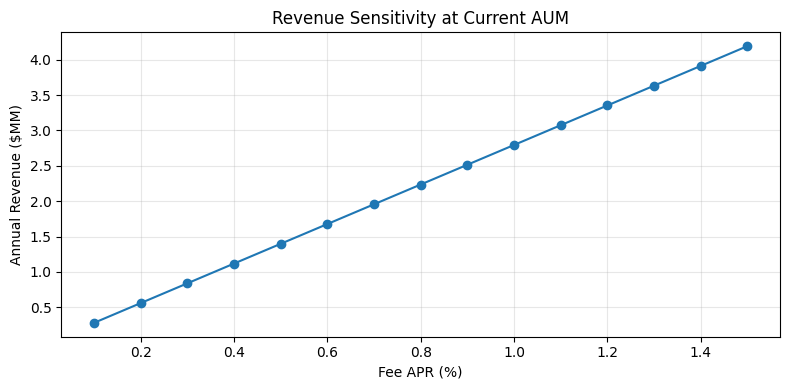

OSError: Cannot save file into a non-existent directory: '/mnt/data'

In [1]:
# %% [markdown]
# # Prediction Market ETFs — Revenue Model (Funding-Fee Only)
# 
# This notebook estimates **annual revenue** for a suite of Prediction-Market ETFs **assuming zero take on trading volume** and **revenue only from funding/management fees**.
# 
# **What you can do here**
# - Set baseline assumptions (number of funds, AUM per fund, fee %, ramp/growth).
# - Compare fee scenarios using reference ranges from “exotic” ETFs (e.g., leveraged/inverse, thematic, crypto).
# - Run quick sensitivity tables and visualize revenue vs. fee rate and AUM scale.
# 
# *Notes:* All fees are modeled as simple annual expense ratios applied to average AUM. You can tweak assumptions below.

# %%
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make tables display nicely
pd.options.display.float_format = lambda x: f"{x:,.2f}"

# %% [markdown]
# ## 1) Assumptions

# %%
@dataclass
class Assumptions:
    # Portfolio configuration
    num_funds: int = 10                 # how many ETFs you operate
    avg_aum_per_fund: float = 25_000_000  # $ per fund (average during the year)
    
    # Fees & waivers
    fee_rate_apr: float = 0.0060        # 0.60% funding/management fee (APR)
    promo_fee_rate_apr: float = 0.0020  # optional intro/promo fee (APR) during ramp
    promo_months: int = 3               # months of promo period w/ reduced fee
    
    # AUM ramp within year (to approximate launches mid-year)
    aum_monthly_growth: float = 0.02    # 2% MoM growth in average AUM per fund
    months: int = 12

base = Assumptions()
base

# %% [markdown]
# ### Helper: compute effective average AUM under a monthly growth ramp

# %%
def average_aum_over_year(start_aum: float, growth: float, months: int = 12) -> float:
    """Average AUM during the year given a start AUM and constant monthly growth rate."""
    aums = [start_aum * ((1 + growth) ** m) for m in range(months)]
    return float(np.mean(aums))

def revenue_from_fees(avg_aum: float, fee_apr: float) -> float:
    """Annual revenue from an APR fee applied to average AUM."""
    return avg_aum * fee_apr

def blended_fee_revenue(avg_aum: float, fee_apr: float, promo_fee_apr: float, promo_months: int) -> float:
    """Annual revenue with a promo fee for some months, then standard fee for the rest."""
    months = 12
    promo_rev = avg_aum * promo_fee_apr * (promo_months / months)
    std_rev   = avg_aum * fee_apr       * ((months - promo_months) / months)
    return promo_rev + std_rev

# %% [markdown]
# ## 2) Baseline revenue

# %%
def compute_baseline(a: Assumptions) -> pd.Series:
    # Compute average AUM per fund over the year (ramp)
    avg_aum = average_aum_over_year(a.avg_aum_per_fund, a.aum_monthly_growth, a.months)
    
    # Total average AUM across funds
    total_avg_aum = avg_aum * a.num_funds
    
    # Revenue with and without promo
    rev_no_promo = revenue_from_fees(total_avg_aum, a.fee_rate_apr)
    rev_blended  = blended_fee_revenue(total_avg_aum, a.fee_rate_apr, a.promo_fee_rate_apr, a.promo_months)
    
    return pd.Series({
        "Funds (count)": a.num_funds,
        "Avg AUM per Fund ($)": avg_aum,
        "Total Avg AUM ($)": total_avg_aum,
        "Fee APR (Std)": a.fee_rate_apr,
        "Fee APR (Promo)": a.promo_fee_rate_apr,
        "Promo Months": a.promo_months,
        "Annual Revenue ($) — No Promo": rev_no_promo,
        "Annual Revenue ($) — Blended (Promo)": rev_blended
    })

baseline = compute_baseline(base)
baseline_df = baseline.to_frame(name="Baseline").reset_index().rename(columns={"index": "Metric"})
baseline_df

# %% [markdown]
# ## 3) Comparable fee scenarios (exotic ETFs)
# 
# Reference ranges (recent sources; edit as needed):
# - **Inverse / Leveraged ETFs**: ~**1.0%** typical expense ratio.  
# - **Thematic ETFs**: often **0.40%–0.95%**.  
# - **Spot Bitcoin ETFs (US)**: **0.15%–0.25%** headline fees (some temporary waivers).  
# - **Plain-vanilla index ETFs (for comparison)**: ~**0.10%–0.15%** asset-weighted averages.
# 
# We'll run your model at illustrative points within these ranges.

# %%
fee_scenarios = pd.DataFrame({
    "Scenario": [
        "Plain Index-like",
        "Crypto (Spot BTC-like)",
        "Thematic — Low",
        "Thematic — High",
        "Leveraged/Inverse-like"
    ],
    "Fee_APR": [
        0.0014,   # 0.14%
        0.0020,   # 0.20%
        0.0040,   # 0.40%
        0.0095,   # 0.95%
        0.0100    # 1.00%
    ]
})

def run_scenarios(a: Assumptions, scenarios: pd.DataFrame) -> pd.DataFrame:
    avg_aum = average_aum_over_year(a.avg_aum_per_fund, a.aum_monthly_growth, a.months) * a.num_funds
    out = scenarios.copy()
    out["Annual_Revenue_$"] = out["Fee_APR"] * avg_aum
    out["Avg_Total_AUM_$"]  = avg_aum
    return out

scenario_results = run_scenarios(base, fee_scenarios)
scenario_results

# %% [markdown]
# ### Bar chart: Annual revenue by fee scenario

# %%
plt.figure(figsize=(8,4))
plt.bar(scenario_results["Scenario"], scenario_results["Annual_Revenue_$"] / 1_000_000)
plt.ylabel("Annual Revenue ($MM)")
plt.title("Prediction-Market ETFs — Funding-Fee Revenue by Scenario")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 4) Sensitivity — revenue vs. fee and scale
# 
# The table below shows annual revenue across a grid of:
# - **Total average AUM** (all funds combined), and
# - **Fee APR** (%/year).
# 
# The AUM values implicitly include ramping; treat them as the *average* AUM over the year.

# %%
fee_grid = np.array([0.001, 0.002, 0.004, 0.0075, 0.010, 0.015])  # 0.10% to 1.50%
aum_grid = np.array([25, 50, 100, 250, 500, 1_000]) * 1_000_000   # $25mm to $1bn

sens = pd.DataFrame(
    [[f * a for f in fee_grid] for a in aum_grid],
    index=[f"${a/1_000_000:,.0f}mm" for a in aum_grid],
    columns=[f"{f*100:.2f}%" for f in fee_grid]
)
sens.index.name = "Avg Total AUM"
sens.columns.name = "Fee APR"
sens

# %% [markdown]
# ### Line chart: Revenue vs. fee at your current scale

# %%
current_total_avg_aum = scenario_results["Avg_Total_AUM_$"].iloc[0]
fees = np.linspace(0.001, 0.015, 15)  # 0.10% to 1.50%
revenues = current_total_avg_aum * fees

plt.figure(figsize=(8,4))
plt.plot(fees * 100, revenues / 1_000_000, marker="o")
plt.xlabel("Fee APR (%)")
plt.ylabel("Annual Revenue ($MM)")
plt.title("Revenue Sensitivity at Current AUM")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 5) Tweak the dial — quick what-if
# 
# Edit the `Assumptions(...)` below and re-run the cell to immediately update the model.

# %%
# Example tweak: 15 funds, $40mm average AUM per fund, 0.95% fee, 2-month promo at 0.20%
what_if = Assumptions(
    num_funds=15,
    avg_aum_per_fund=40_000_000,
    fee_rate_apr=0.0095,
    promo_fee_rate_apr=0.0020,
    promo_months=2,
    aum_monthly_growth=0.02,
    months=12
)

what_if_summary = compute_baseline(what_if).to_frame(name="What-If").reset_index().rename(columns={"index": "Metric"})
what_if_summary

# %% [markdown]
# ---
# ### Next steps you might want
# - Add **per-fund fixed platform costs** to turn revenue into *contribution margin*.
# - Model **launch cadence** (staggered fund starts) and **AUM decay** on closures.
# - Add **fee waivers** by cohort and **asset-based breakpoints**.
# - Export to CSV for your deck.

# %%
# Save outputs for reference
scenario_results.to_csv("/mnt/data/pm_etf_fee_scenarios.csv", index=False)
sens.to_csv("/mnt/data/pm_etf_fee_sensitivity.csv")

print("Saved:")
print("- /mnt/data/pm_etf_fee_scenarios.csv")
print("- /mnt/data/pm_etf_fee_sensitivity.csv")


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========== PHASE 1: Boutique (high fee, low AUM) ==========
fees_boutique = np.linspace(0.02, 0.10, 9)         # 2% → 10%
aum_boutique = np.linspace(1, 100, 10) * 1_000_000 # $1M → $100M

rev_boutique = pd.DataFrame(
    [[fee * aum for aum in aum_boutique] for fee in fees_boutique],
    index=[f"{fee*100:.1f}%" for fee in fees_boutique],
    columns=[f"${aum/1_000_000:,.0f}M" for aum in aum_boutique]
) / 1_000_000  # convert to $MM

# ========== PHASE 2: Mature (low fee, high AUM) ==========
fees_mature = np.linspace(0.0025, 0.03, 12)        # 0.25% → 3%
aum_mature = np.linspace(50, 1000, 10) * 1_000_000 # $50M → $1B

rev_mature = pd.DataFrame(
    [[fee * aum for aum in aum_mature] for fee in fees_mature],
    index=[f"{fee*100:.2f}%" for fee in fees_mature],
    columns=[f"${aum/1_000_000:,.0f}M" for aum in aum_mature]
) / 1_000_000  # convert to $MM

# ========== PLOT ==========
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.heatmap(rev_boutique, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Boutique Phase — High Fees, Low AUM\n(Annual Revenue $MM)")

sns.heatmap(rev_mature, annot=True, fmt=".1f", cmap="YlOrBr", ax=axes[1])
axes[1].set_title("Mature Phase — Lower Fees, Higher AUM\n(Annual Revenue $MM)")

plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'seaborn'

/tmp/ipykernel_28506/659450639.py:34: RuntimeWarning: divide by zero encountered in divide
  n = np.where(denom > 0, dev_cost / denom, np.nan)


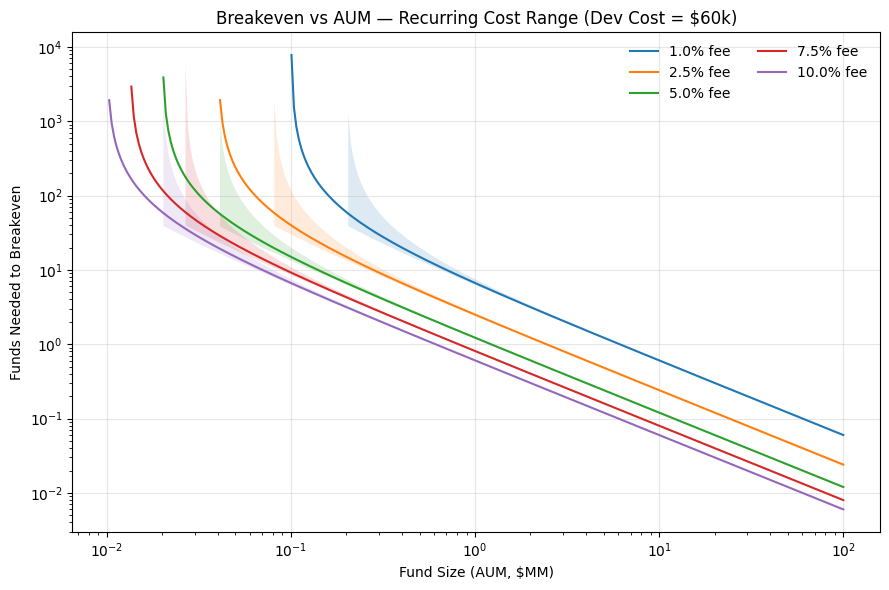

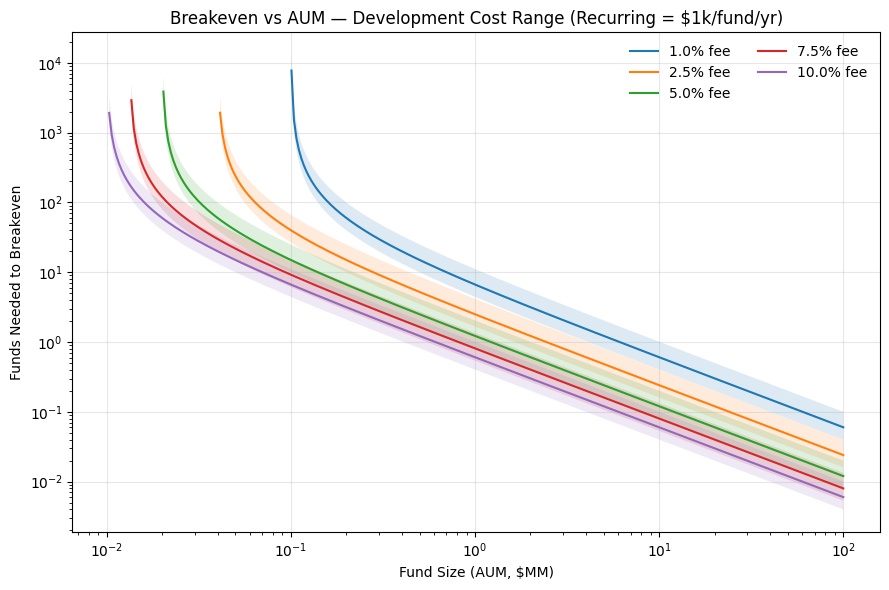

ModuleNotFoundError: No module named 'caas_jupyter_tools'

In [1]:
# %% [markdown]
# # Breakeven Analysis with Cost Ranges
# 
# We extend the prior log–log breakeven chart to handle **ranges** for:
# - **Development overhead** (one-time): low/base/high
# - **Annual recurring per-fund cost**: low/base/high
# 
# Breakeven condition: `FundsNeeded = DevCost / (AUM * Fee - AnnualPerFundCost)`
# 
# Notes:
# - Where `(AUM * Fee - AnnualPerFundCost) <= 0`, breakeven is not possible → shown as gaps (NaN).
# - We plot two charts:
#   1) **Recurring-cost range** bands (at base development cost).
#   2) **Development-cost range** bands (at base recurring cost).
# - Axes are logarithmic to show both boutique and mature regimes clearly.

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- PARAMETERS ----------
fees = [0.01, 0.025, 0.05, 0.075, 0.10]         # 1% → 10%
aum = np.logspace(4, 8, 300)                    # $10k → $100M

# Cost ranges
dev_low, dev_base, dev_high = 40_000, 60_000, 100_000
rec_low, rec_base, rec_high = 500, 1_000, 2_000

def breakeven_funds(aum_array, fee, dev_cost, annual_cost):
    rev_per_fund = aum_array * fee
    denom = rev_per_fund - annual_cost
    # Avoid invalid / non-positive denominators
    n = np.where(denom > 0, dev_cost / denom, np.nan)
    return n

# ---------- PLOT 1: Recurring cost range (base dev cost) ----------
plt.figure(figsize=(9,6))
for fee in fees:
    # Base recurring line
    n_base = breakeven_funds(aum, fee, dev_base, rec_base)
    # Range band from low to high recurring cost
    n_low  = breakeven_funds(aum, fee, dev_base, rec_low)
    n_high = breakeven_funds(aum, fee, dev_base, rec_high)
    # Plot band and base line
    plt.fill_between(aum/1e6, n_low, n_high, alpha=0.15)
    plt.plot(aum/1e6, n_base, label=f"{fee*100:.1f}% fee")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fund Size (AUM, $MM)")
plt.ylabel("Funds Needed to Breakeven")
plt.title("Breakeven vs AUM — Recurring Cost Range (Dev Cost = $60k)")
plt.legend(ncols=2, frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- PLOT 2: Development cost range (base recurring cost) ----------
plt.figure(figsize=(9,6))
for fee in fees:
    # Base development line
    n_base = breakeven_funds(aum, fee, dev_base, rec_base)
    # Range band from low to high dev cost
    n_low  = breakeven_funds(aum, fee, dev_low,  rec_base)
    n_high = breakeven_funds(aum, fee, dev_high, rec_base)
    plt.fill_between(aum/1e6, n_low, n_high, alpha=0.15)
    plt.plot(aum/1e6, n_base, label=f"{fee*100:.1f}% fee")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fund Size (AUM, $MM)")
plt.ylabel("Funds Needed to Breakeven")
plt.title("Breakeven vs AUM — Development Cost Range (Recurring = $1k/fund/yr)")
plt.legend(ncols=2, frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- SUMMARY TABLE (discrete points) ----------
aum_points = [1e5, 1e6, 1e7]  # $0.1M, $1M, $10M
rows = []
for a in aum_points:
    for f in fees:
        n_min = breakeven_funds(np.array([a]), f, dev_low, rec_low)[0]
        n_mid = breakeven_funds(np.array([a]), f, dev_base, rec_base)[0]
        n_max = breakeven_funds(np.array([a]), f, dev_high, rec_high)[0]
        rows.append({
            "Fund Size": f"${a/1e6:.1f}M",
            "Fee": f"{f*100:.1f}%",
            "Funds to Breakeven (min cost)": None if np.isnan(n_min) else round(float(n_min), 2),
            "Funds to Breakeven (base)": None if np.isnan(n_mid) else round(float(n_mid), 2),
            "Funds to Breakeven (max cost)": None if np.isnan(n_max) else round(float(n_max), 2),
        })

summary_df = pd.DataFrame(rows)
from caas_jupyter_tools import display_dataframe_to_user
display_dataframe_to_user("Breakeven sensitivity (AUM × Fee with cost ranges)", summary_df)


/tmp/ipykernel_28506/2862534882.py:27: RuntimeWarning: divide by zero encountered in divide
  n = np.where(denom > 0, overhead / denom, np.nan)


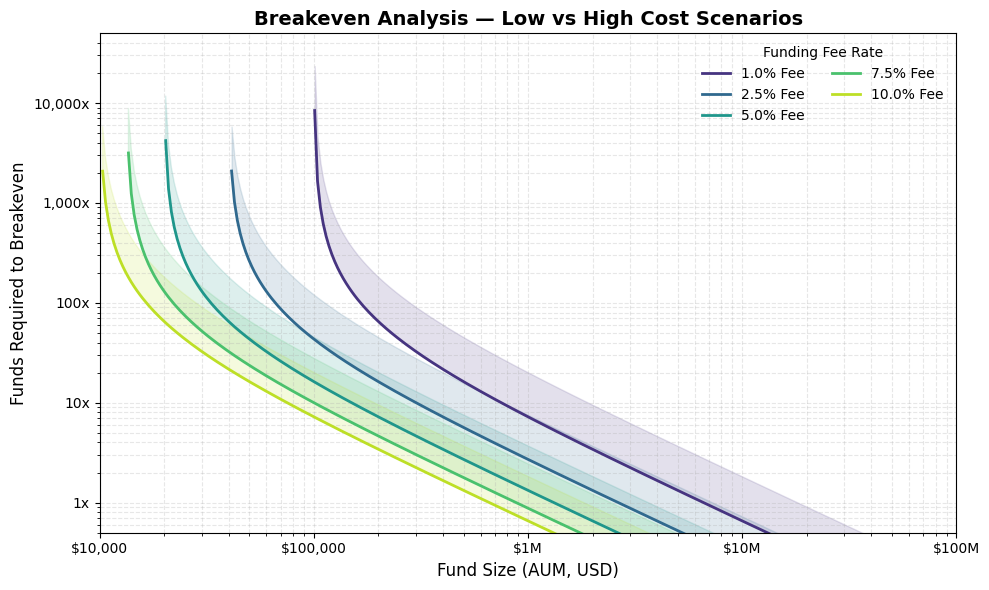


Breakeven summary (low vs high cost scenarios):

Fund Size   Fee  Breakeven Funds (Low Cost)  Breakeven Funds (High Cost)
    $0.1M  1.0%                         NaN                          NaN
    $0.1M  2.5%                       43.33                       120.67
    $0.1M  5.0%                       16.25                        45.25
    $0.1M  7.5%                       10.00                        27.85
    $0.1M 10.0%                        7.22                        20.11
    $1.0M  1.0%                        7.22                        20.11
    $1.0M  2.5%                        2.71                         7.54
    $1.0M  5.0%                        1.33                         3.69
    $1.0M  7.5%                        0.88                         2.45
    $1.0M 10.0%                        0.66                         1.83
   $10.0M  1.0%                        0.66                         1.83
   $10.0M  2.5%                        0.26                         0.73
 

In [8]:
# %% [markdown]
# # Breakeven Analysis — Updated with New Cost Model (2025)
#
# Saves a high-res PNG of the breakeven plot and outputs a summary table.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---------- PARAMETERS ----------
fees = [0.01, 0.025, 0.05, 0.075, 0.10]      # 1% → 10%
aum = np.logspace(4, 8, 300)                 # $10k → $100M
recurring_cost_per_fund = 1_000

# Cost ranges from updated report
dev_low, dev_high = 49_000, 116_000
fixed_low, fixed_high = 16_000, 65_000

# Total overheads (development + fixed annual)
overhead_low  = dev_low  + fixed_low   # 65k
overhead_high = dev_high + fixed_high  # 181k

def breakeven_funds(aum_array, fee, overhead, recurring):
    rev_per_fund = aum_array * fee
    denom = rev_per_fund - recurring
    n = np.where(denom > 0, overhead / denom, np.nan)
    return n

# ---------- PLOT: Low vs High Cost Scenarios ----------
plt.figure(figsize=(10,6))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(fees)))

for i, fee in enumerate(fees):
    n_low  = breakeven_funds(aum, fee, overhead_low,  recurring_cost_per_fund)
    n_high = breakeven_funds(aum, fee, overhead_high, recurring_cost_per_fund)
    
    # Shaded range between low/high cost cases
    plt.fill_between(aum/1e6, n_low, n_high, alpha=0.15, color=colors[i])
    plt.plot(aum/1e6, n_low,  lw=2, color=colors[i], label=f"{fee*100:.1f}% Fee")

plt.xscale("log")
plt.yscale("log")

# Format axes nicely (no scientific notation)
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}M" if x >= 1 else f"${x*1e6:,.0f}")
)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f"{y:,.0f}x")
)

plt.ylim(0.5, None)
plt.xlim(aum[0]/1e6, aum[-1]/1e6)

plt.xlabel("Fund Size (AUM, USD)", fontsize=12)
plt.ylabel("Funds Required to Breakeven", fontsize=12)
plt.title("Breakeven Analysis — Low vs High Cost Scenarios", fontsize=14, weight="bold")
plt.legend(title="Funding Fee Rate", ncols=2, frameon=False)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig("breakeven_cost_range.png", dpi=240)
plt.show()

# ---------- SUMMARY TABLE ----------
aum_points = [1e5, 1e6, 1e7]
rows = []
for a in aum_points:
    for f in fees:
        n_low  = breakeven_funds(np.array([a]), f, overhead_low,  recurring_cost_per_fund)[0]
        n_high = breakeven_funds(np.array([a]), f, overhead_high, recurring_cost_per_fund)[0]
        rows.append({
            "Fund Size": f"${a/1e6:.1f}M",
            "Fee": f"{f*100:.1f}%",
            "Breakeven Funds (Low Cost)": None if np.isnan(n_low) else round(float(n_low), 2),
            "Breakeven Funds (High Cost)": None if np.isnan(n_high) else round(float(n_high), 2),
        })

breakeven_summary = pd.DataFrame(rows)
print("\nBreakeven summary (low vs high cost scenarios):\n")
print(breakeven_summary.to_string(index=False))

# Save CSV
breakeven_summary.to_csv("breakeven_summary_low_high.csv", index=False)
print("\nSaved:")
print(" - breakeven_cost_range.png")
print(" - breakeven_summary_low_high.csv")


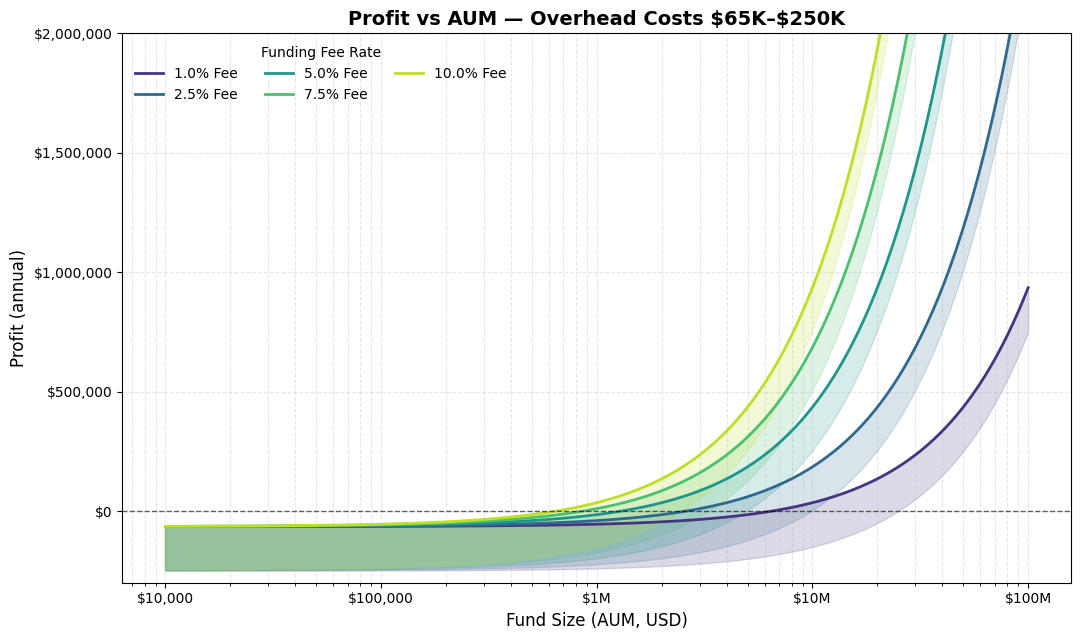


Breakeven AUM by Fee (Overhead $65K–$250K):

  Fee Breakeven AUM (Low Overhead) Breakeven AUM (High Overhead)          Range
 1.0%                   $6,500,000                   $25,000,000 $6.50M–$25.00M
 2.5%                   $2,600,000                   $10,000,000 $2.60M–$10.00M
 5.0%                   $1,300,000                    $5,000,000  $1.30M–$5.00M
 7.5%                     $866,667                    $3,333,333  $0.87M–$3.33M
10.0%                     $650,000                    $2,500,000  $0.65M–$2.50M

Saved:
 - aum_profit_band_display_capped.png
 - aum_breakeven_band_summary.csv


In [21]:
# %% [markdown]
# # Breakeven Analysis — AUM-Only with Cost Bands (Readability: Y-axis capped at $2M)
#
# Profit = AUM * fee − overhead
# Overhead band: $65k–$300k
# Display only: y-axis capped at $2,000,000 for readability

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---------- PARAMETERS ----------
fees = [0.01, 0.025, 0.05, 0.075, 0.10]      # 1%, 2.5%, 5%, 7.5%, 10%
aum = np.logspace(4, 8, 300)                 # $10k → $100M
overhead_low, overhead_high = 65_000, 250_000
ymax = 2_000_000                             # display cap (NOT a model cap)

# ---------- FUNCTIONS ----------
def profit(aum_array, fee, overhead):
    return aum_array * fee - overhead

def breakeven_aum(fee, overhead):
    return overhead / fee if fee > 0 else np.nan

# ---------- PLOT ----------
plt.figure(figsize=(11,6.5))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(fees)))

ymin = None
for i, f in enumerate(fees):
    low_line  = profit(aum, f, overhead_low)
    high_line = profit(aum, f, overhead_high)

    # shaded band between low/high overhead profit lines
    plt.fill_between(aum/1e6, low_line, high_line, alpha=0.18, color=colors[i])
    # outline the low-overhead boundary for legend (matches earlier styling)
    plt.plot(aum/1e6, low_line, lw=2, color=colors[i], label=f"{f*100:.1f}% Fee")

    m = min(low_line.min(), high_line.min())
    ymin = m if ymin is None else min(ymin, m)

# reference zero line
plt.axhline(0, lw=1, ls="--", alpha=0.6, color="black")

# axis formatting
plt.xscale("log")
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}M" if x >= 1 else f"${x*1e6:,.0f}")
)
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

plt.xlabel("Fund Size (AUM, USD)", fontsize=12)
plt.ylabel("Profit (annual)", fontsize=12)
plt.title(r"Profit vs AUM — Overhead Costs \$65K–\$250K", fontsize=14, weight="bold")
plt.legend(title="Funding Fee Rate", ncols=3, frameon=False)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

# y-range for readability (show a bit below min so the negative region is visible)
plt.ylim(min(-300_000, ymin*1.05), ymax)

plt.savefig("aum_profit_band_display_capped.png", dpi=240)
plt.show()

# ---------- TABLE ----------
rows = []
for f in fees:
    low_be  = breakeven_aum(f, overhead_low)
    high_be = breakeven_aum(f, overhead_high)
    rows.append({
        "Fee": f"{f*100:.1f}%",
        "Breakeven AUM (Low Overhead)": f"${low_be:,.0f}",
        "Breakeven AUM (High Overhead)": f"${high_be:,.0f}",
        "Range": f"${low_be/1e6:.2f}M–${high_be/1e6:.2f}M"
    })

breakeven_table = pd.DataFrame(rows)
print("\nBreakeven AUM by Fee (Overhead $65K–$250K):\n")
print(breakeven_table.to_string(index=False))

breakeven_table.to_csv("aum_breakeven_band_summary.csv", index=False)
print("\nSaved:")
print(" - aum_profit_band_display_capped.png")
print(" - aum_breakeven_band_summary.csv")
